## February 18, 2026

In [37]:
# installing seaborn, we can load all the packages we’ll be using in this lesson

import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy
import PIL
import requests

np.random.seed (613)

In [3]:
# work with the ‘tips’ sample dataset, which is available as part of theseaborn (sns) package
# information about tips at a restaurant, including meal time, partysize, gender of customer, total bill amount, and tip amount

tips = sns.load_dataset("tips")
print(tips)

     total_bill   tip     sex smoker   day    time  size
0         16.99  1.01  Female     No   Sun  Dinner     2
1         10.34  1.66    Male     No   Sun  Dinner     3
2         21.01  3.50    Male     No   Sun  Dinner     3
3         23.68  3.31    Male     No   Sun  Dinner     2
4         24.59  3.61  Female     No   Sun  Dinner     4
..          ...   ...     ...    ...   ...     ...   ...
239       29.03  5.92    Male     No   Sat  Dinner     3
240       27.18  2.00  Female    Yes   Sat  Dinner     2
241       22.67  2.00    Male    Yes   Sat  Dinner     2
242       17.82  1.75    Male     No   Sat  Dinner     2
243       18.78  3.00  Female     No  Thur  Dinner     2

[244 rows x 7 columns]


<Axes: xlabel='total_bill', ylabel='tip'>

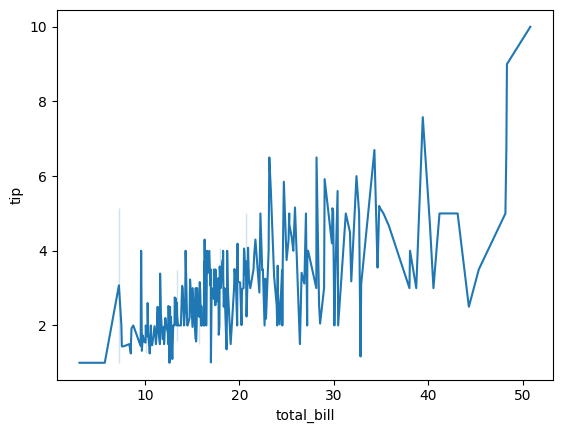

In [4]:
# simple line plot of tip amount vs total bill
sns.lineplot(data=tips, # choose our dataset 
             x='total_bill', # define our x variable 
             y='tip') # define our y variable

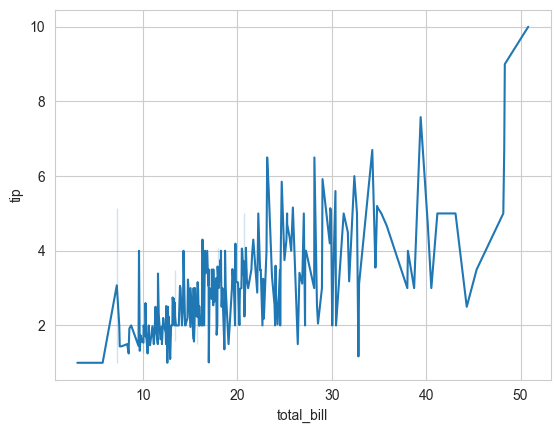

In [6]:
# premade styles to alter the appearance of our plot
sns.lineplot(data=tips, 
             x='total_bill', 
             y='tip')
sns.set_style('whitegrid')

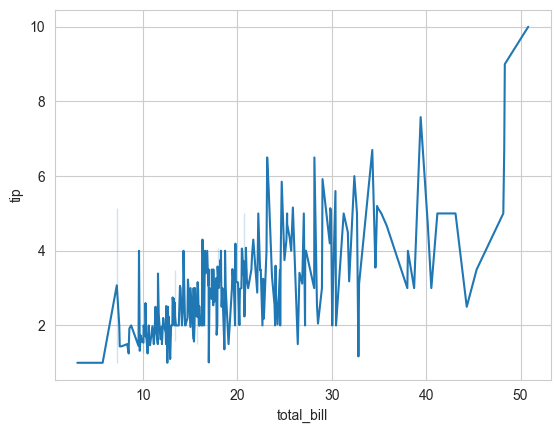

In [7]:
# Try other preset styles like ‘darkgrid’, ‘whitegrid’, ‘dark’, ‘white’, ‘ticks’, then make our lineplot again
sns.lineplot(data=tips, 
             x='total_bill', 
             y='tip')
sns.set_style('darkgrid')

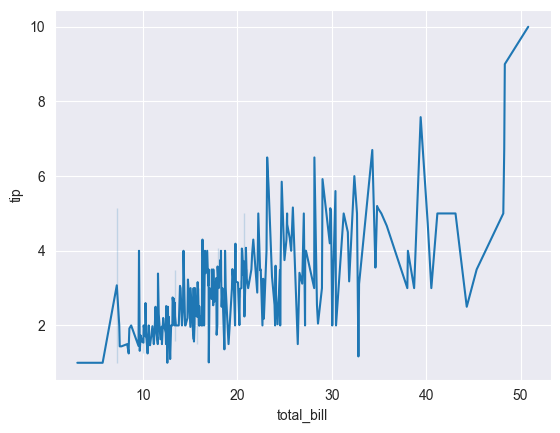

In [8]:
sns.lineplot(data=tips, 
             x='total_bill', 
             y='tip')
sns.set_style('white')

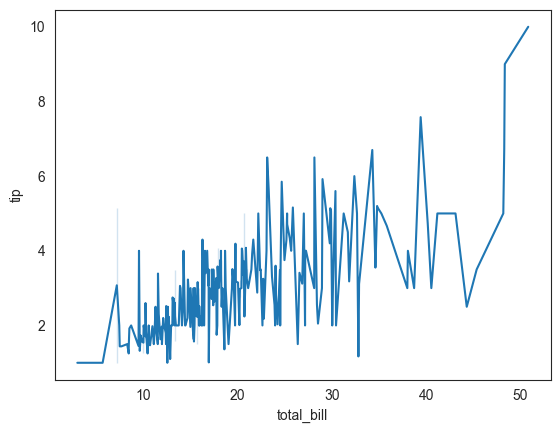

In [9]:
sns.lineplot(data=tips, 
             x='total_bill', 
             y='tip')
sns.set_style('ticks')

[Text(0.5, 1.0, 'Tips vs. Total Bill'),
 Text(0.5, 0, 'Total Bill ($)'),
 Text(0, 0.5, 'Tip Amount ($)')]

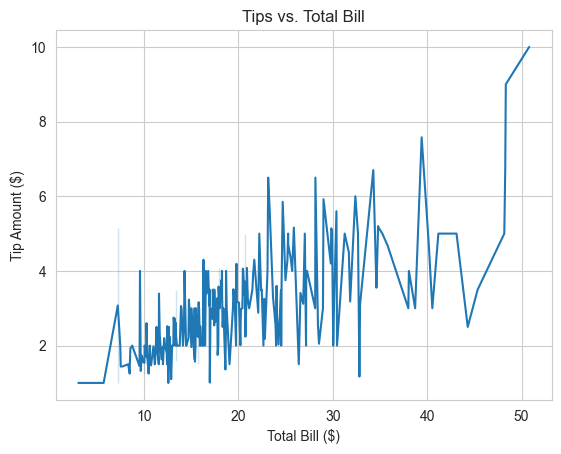

In [38]:
# Seaborn can do many of the same things as matplotlib, like adding labels using the set.function
sns.set_style('whitegrid')
tipgraph = sns.lineplot(data=tips, 
                        x='total_bill', 
                        y='tip')

tipgraph.set(title='Tips vs. Total Bill', 
             xlabel='Total Bill ($)', 
             ylabel='Tip Amount ($)')

[Text(0.5, 1.0, 'Tips vs. Total Bill'),
 Text(0.5, 0, 'Total Bill ($)'),
 Text(0, 0.5, 'Tip Amount ($)')]

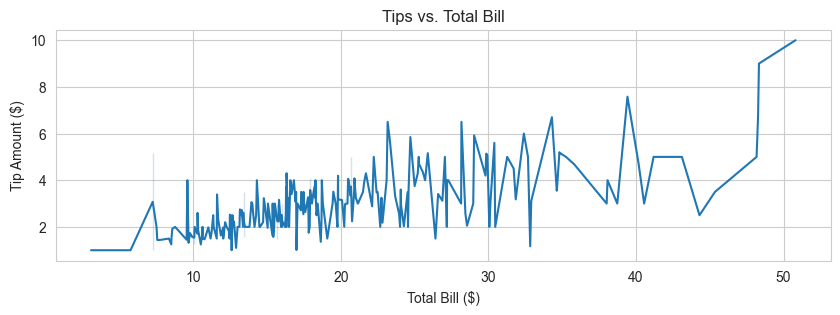

In [39]:
# Modify aesthetic elements
sns.set_style('whitegrid')
fig = plt.subplots(figsize=(10, 3))
tipgraph = sns.lineplot(data=tips, 
                        x='total_bill', 
                        y='tip')

tipgraph.set(title='Tips vs. Total Bill', 
             xlabel='Total Bill ($)', 
             ylabel='Tip Amount ($)')

[Text(0.5, 1.0, 'Tips vs. Total Bill'),
 Text(0.5, 0, 'Total Bill ($)'),
 Text(0, 0.5, 'Tip Amount ($)')]

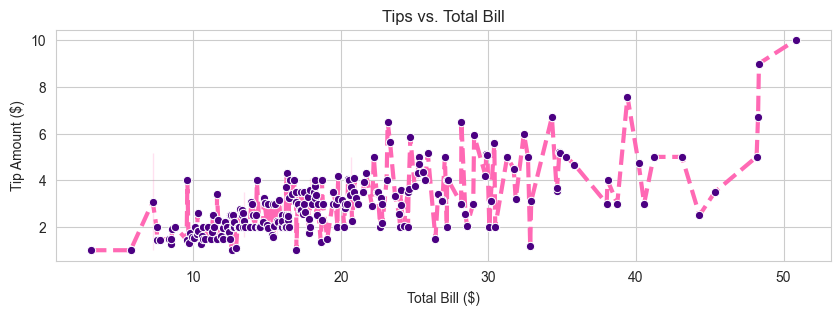

In [41]:
# change colour, marker style, and line style
sns.set_style('whitegrid')
fig = plt.subplots(figsize=(10, 3))
tipgraph = sns.lineplot(data=tips, 
                        x='total_bill', 
                        y='tip', 
                        color = 'hotpink', 
                        linestyle = '--', 
                        linewidth = 3, 
                        marker = 'o', 
                        markerfacecolor = 'indigo')

tipgraph.set(title='Tips vs. Total Bill', 
             xlabel='Total Bill ($)', 
             ylabel='Tip Amount ($)')

[Text(0.5, 1.0, 'Tips vs. Total Bill'),
 Text(0.5, 0, 'Total Bill ($)'),
 Text(0, 0.5, 'Tip Amount ($)')]

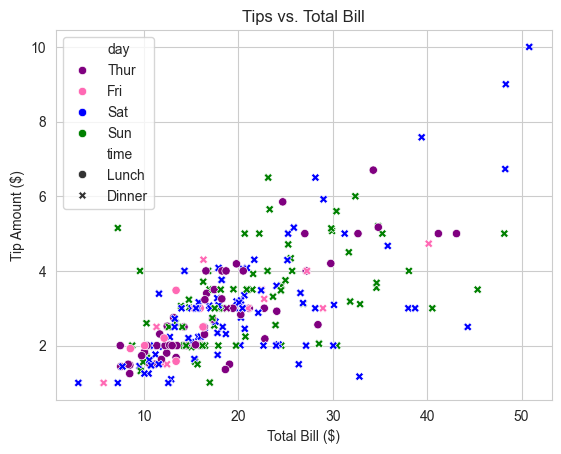

In [40]:
# Add multiple variables
tipgraph = sns.scatterplot(data=tips, 
                           x='total_bill', 
                           y='tip', 
                           style = 'time', 
                           hue = 'day', 
                           palette = ['purple', 'hotpink', 'blue', 'green'])

tipgraph.set(title='Tips vs. Total Bill', 
             xlabel='Total Bill ($)', 
             ylabel='Tip Amount ($)')

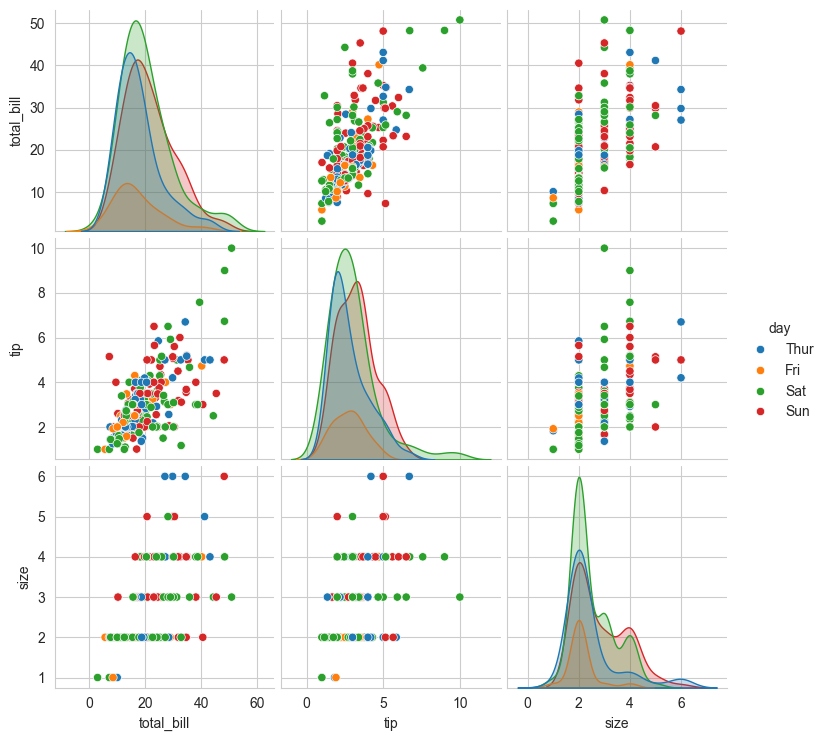

In [42]:
# pairplot is another convenient way to compare variables
sns.pairplot( data = tips, hue = 'day')

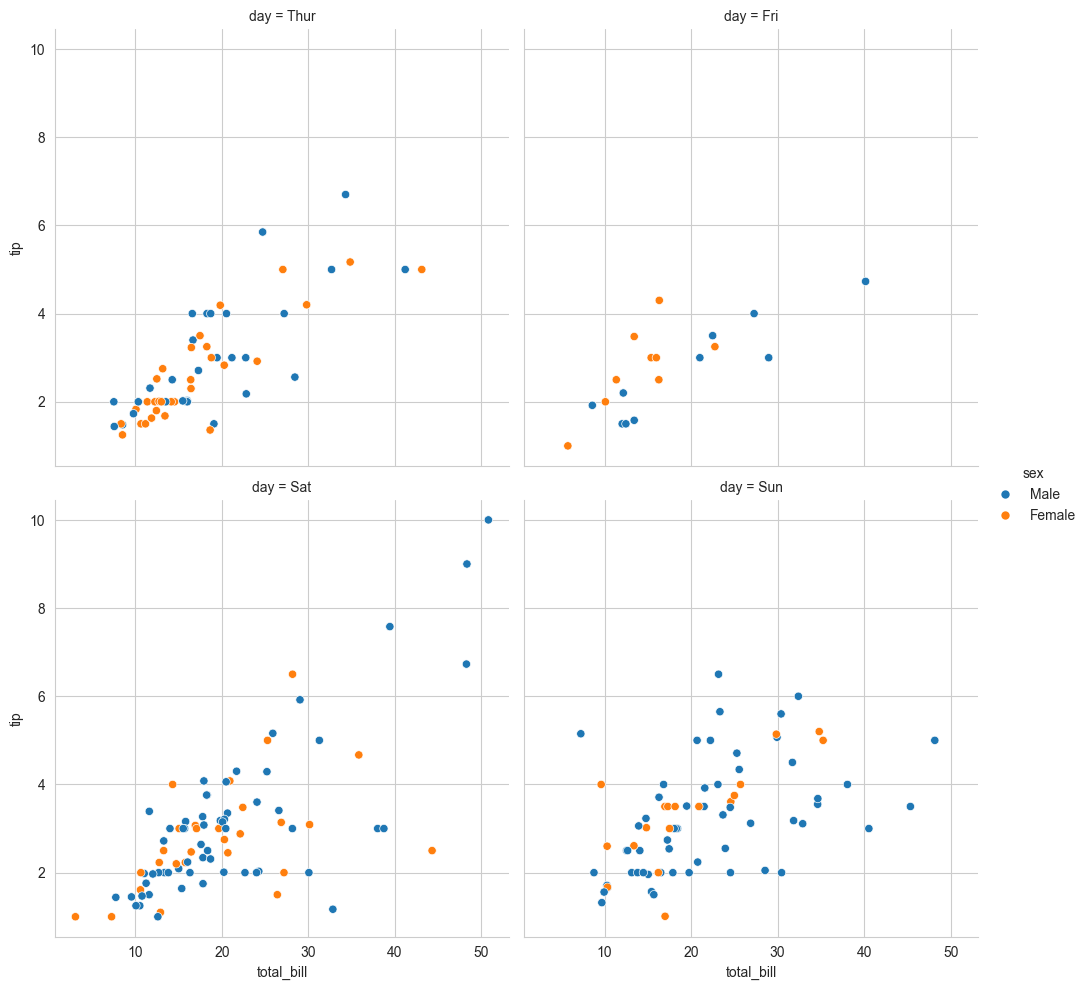

In [44]:
# relplot lets us explore specific levels within variables
daysplot = sns.relplot( data=tips, 
                       x="total_bill", 
                       y="tip", 
                       hue="sex", 
                       col="day", 
                       kind="scatter", 
                       col_wrap=2)
daysplot

In [23]:
# Plotly
# import our package and make some sample data
import plotly.graph_objects as go # 'go' is 'graph objects’

x1 = np.array(["Luffy", "Zoro", "Nami", "Usopp", "Sanji"])
y1 = np.array([110, 180, 240, 99, 220])

In [25]:
# Plotly syntax is different from matplotlib/seaborn
# make our figure
graph = go.Figure() 

# Next, choose our plot type (bar) and our data
graph.add_trace(go.Bar(x=x1, y=y1))

# Next, update our layout to include titles
graph.update_layout( 
    title="Pirate Scores", 
    xaxis_title="Pirates", 
    yaxis_title="Score")

# Finally, show our plot
graph.show()

In [ ]:
# Customizing plotly graphs
graph = go.Figure()
graph.add_trace(go.Scatter(x=x1, 
                           y=y1, 
                           mode='markers', # we want points for a scatter plot
                           marker=dict(size=15, # point size
                                       color='hotpink', # point colour
                                       opacity=1, # point transparency/alpha
                                       line=dict(width=5, color='purple')))) # point outline 

graph.update_layout(title='Interactive Pirate Plot',
                    xaxis_title='Pirates',
                    yaxis_title='Scores',
                    width=500,
                    height=500)

#### Wordclouds and venn diagrams

In [27]:
# Making wordclouds
# Import the wordcloud package and load our sample dataset of movie quotes
from wordcloud import WordCloud
df = pd.read_csv("https://raw.githubusercontent.com/prasertcbs/basic-dataset/master/movie_quotes.csv",
                 on_bad_lines='skip')
df

,quote,movie,type,year
0,"Do, or do not. There is no try.",Star Wars: Episode V - The Empire Strikes Back,movie,1890
1,Listen to them. Children of the night. What mu...,Dracula,movie,1931
2,It's alive! It's alive!,Frankenstein,movie,1931
3,"Oh, no, it wasn't the airplanes. It was Beauty...",King Kong,movie,1933
4,"Magic Mirror on the wall, who is the fairest o...",Snow White and the Seven Dwarves,movie,1937
...,...,...,...,...
727,I didn't know if you were lost. Stick with me....,Us,movie,2019
728,This guy's awesome! He's holding his own while...,Dragon Ball Super: Broly,movie,2019
729,"Murder is murder, it don’t matter who you are.",Black and Blue,movie,2019
730,You know what a lion is? A lion is a strong an...,Between Two Ferns: The Movie,movie,2019


(np.float64(-0.5), np.float64(399.5), np.float64(199.5), np.float64(-0.5))

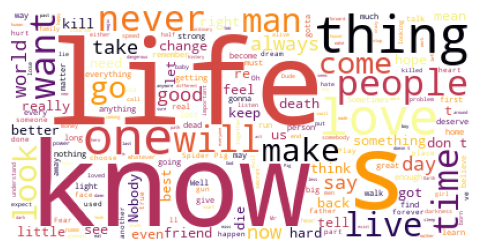

In [ ]:
# Making wordclouds
# make a simple word cloud using the ‘quote’ variable

# join all our text from each row from our quote column into a string
text = " ".join(each for each in df.quote)

# generate our wordcloud image
wordcloud = WordCloud(background_color="white",
                      colormap = 'inferno',
                      random_state=613).generate(text) # random _state for reproducibility

# use matplotlib syntax to put our image in a figure
fig, ax = plt.subplots(figsize=(7, 3))
ax.imshow(wordcloud), # remember 'imshow' from when we added pictures to our matplotlib axes 
ax.axis("off")

(np.float64(-0.5), np.float64(399.5), np.float64(199.5), np.float64(-0.5))

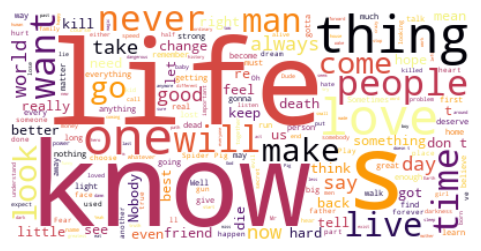

In [30]:
text = " ".join(each for each in df.quote)

# generate our wordcloud image
wordcloud = WordCloud(background_color="white",
                      colormap = 'inferno',
                      random_state=613).generate(text)

# use matplotlib syntax to put our image in a figure
fig, ax = plt.subplots(figsize=(7, 3))
ax.imshow(wordcloud, # remember 'imshow' from when we added pictures to our matplotlib axes 
          interpolation='bilinear') # this line helps smooth our image
ax.axis("off")

#### Making venn diagrams

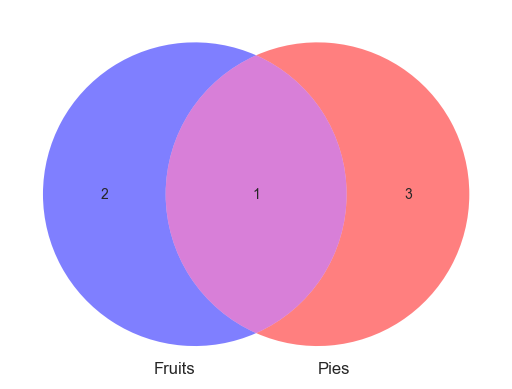

In [33]:
# use the matplotlib_venn extension to make venn diagrams
# import the package
from matplotlib_venn import venn2, venn2_circles, venn2_unweighted

# define our sets
A = set(["apple", "banana", "watermelon"])
B = set(["pumpkin", "blueberry", "apple", "key lime"])

# assign our sets to each circle and modify the appearance
diagram = venn2_unweighted([A, B], 
                           set_labels = ('Fruits', 'Pies'), 
                           set_colors=("blue", "red"), 
                           alpha=0.5) # alpha is transparency

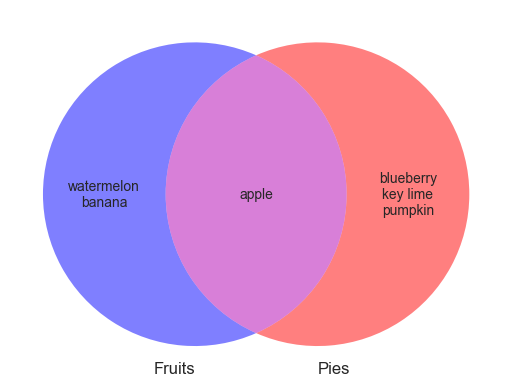

In [36]:
# Modifying venn diagrams
A = set(["apple", "banana", "watermelon"])
B = set(["pumpkin", "blueberry", "apple", "key lime"])

diagram = venn2_unweighted([A, B], 
                           set_labels = ('Fruits', 'Pies'), 
                           set_colors=("blue", "red"), 
                           alpha=0.5)

diagram.get_label_by_id("10").set_text("\n".join(A - B)) # left
diagram.get_label_by_id("11").set_text("\n".join(A & B)) # middle
diagram.get_label_by_id("01").set_text("\n".join(B - A)) # right